# Simulating Y2H screens

## Model Derivation

In `simulate_experiment.ipynb`, I focused primarily on FACS, as it is more straight forward to model via biophysics. Y2H is a bit more challenging as what happens inside the cell is a bit of a black box. Here, we'll do our best to derive something that we can at least extract some trends from.

In FACS, the transfer function was as follows: Stability + Binding -> Fluorescence -> Probability of sorting. 

For Y2H, it's Stability + Binding -> Transcription of HIS3 -> Histidine production -> Growth rate

As before, we have the probability of folding variant, v:

$$
P_{fold,v} = \frac{1}{1 + e^{\Delta G_{fold,v} / RT}}
$$

And the probability that a folded mutant is bound to its binding partner:

$$
P_{bind,v} = \frac{[L]^{n_{Hill}}}{[L]^{n_{Hill}} + (K_{d,v})^{n_{Hill}}}
$$

There's just one problem, which is that we don't know the concentration of L inside the cell. We'll come back to this later, as there may be a way to solve for this using the plate assays of interactions with known binding affinity. But for now, we'll set this as a guess and we can look at how the trends change.

When bound together, the transcription factor is reconstituted. For now we will assume that HIS3 transcription isn't maxed-out before full saturation of binding. 

We will also assume that the HIS3 enzyme is the limiting factor in histidine synthesis, so that the transcriptional signal for HIS3 is directly proportional to the amount of histidine produced. 

With those assumptions, we can say that the limiting substrate concentration, [S], is proportional to concentration of active transcription factors (bound partners)

$$
[S] = \alpha \cdot [M]_{max} \cdot P_{fold} \cdot P_{bind}
$$

Where $[M]_{max}$ is the maximum concentration possible of the mutant if it were perfectly stable, and $\alpha$ is a proportionality constant.

To model cellular growth rate as a function of the limiting substrate, there exists the Monod equation:

$$
\mu = \mu_{max} \cdot \frac{[S]}{K_s + [S]}
$$

where $\mu$ is the growth rate, $\mu_{max}$ is the maximum growth rate, $[S]$ is the concentration of limiting substrate for growth and $K_s$ is the half-velocity constant, the value of $[S]$ when the growth rate is half of its maximum.

However, the growth rate can also be modified by the addition of the inhibitor, 3-AT. 3-AT is a competitive inhibitor. If you had infinite enzyme, you'd still have the maximum possible production rate, so the inhibitor is actually increasing the amount of enzyme required to achieve the same catalytic rate. We are also assuming in our system that increasing the amount of enzyme directly increases the amount of limiting substrate. So in effect, adding inhibitor directly increases the amount of enzyme needed to produce the same signal, increasing the amount of limiting substrate concentration potential needed. In other words, it increases $K_{s}$.

How does it change $K_{s}$? As a competitive inhibitor, it follows Michaelis-Menten kinetics:

$$
K_m^{app} = K_m \cdot (1 + \frac{[I]}{K_i})
$$

So to apply this to our model, we simply swap $K_m$ for $K_s$, which we are directly proportional by our assumptions, giving us the following for the growth rate:

$$
\mu = \mu_{max} \cdot \frac{[S]}{K_s \cdot (1 + \frac{[I]}{K_i} )+ [S]}
$$

The final abundance of the variant depends on its initial abundance in the library, its growth rate, and the time of selection.

$$
N_{final} = N_{initial} \cdot e^{\mu \cdot t}
$$

For sampling, we will specify a number of miniprep input cells ($N_{samp}$), so the variant abundance going into template extraction will be a multinomial distribution where the probability of selecting a variant is given by its final frequency in the flask at harvest.

So, the probability of picking any specific variant is:

$$
p_i = \frac{N_{final, v}}{N_{total}}
$$

and the number of cells that make it into the pellet for extraction is given by:

$$
N_{pellet} \sim \text{Multinomial}(n=N_{samp}, p={p_1,...p_k})
$$

Then from here, the sequence sampling steps in `simulate_experiment.ipynb` apply.

Now, as this model stands, there are several unknowns. We don't know what $\alpha$, $[M]_{max}$, [S], $K_s$, or $K_i$ (the $K_i$ against purified enzyme isn't applicable because it needs to diffuse into the cell) is. But, if we can calculate things relative to wild-type, we can factor some of these things out!

We'll assume that we have the wild-type $\Delta G$ and the $\Delta \Delta G$ for each variant. We can calculate the $\Delta G$ of the variant as:

$$
\Delta G_v = \Delta G_{WT} + \Delta \Delta G_v
$$

We can calculate probability of folding as above for WT and the variant, then calculate the relative stability of the variants as:

$$
R_{fold} = \frac{P_{fold, v}}{P_{fold, WT}}
$$

and relative affinity as:

$$
R_{bind} = \frac{P_{bind, v}}{P_{bind, WT}}
$$

Now we compute the relative limiting substrate concentration. 

$$
S_{rel} = \frac{\alpha \cdot [M]_{max} \cdot P_{fold, v} \cdot P_{bind, v}}{\alpha \cdot [M]_{max} \cdot P_{fold, WT} \cdot P_{bind, WT}} = R_{fold} \cdot R_{bind}
$$

How cool is that! Two unknowns down.

Now the next challenge is dealing with $K_s$ and $K_i$. These are things that can be empirically calibrated if you have some information on hand. Here's how we could do that.

Firstly, we have our growth rate equation again now in terms of $S_{rel}$.

$$
\mu = \mu_{max} \cdot \frac{S_{rel}}{K_s \cdot (1 + \frac{[I]}{K_i} )+ S_{rel}}
$$

Focusing first on $K_s$, we can simplify this if we look at the growth rate of the WT without 3-AT. The inhibitor term goes to 1, and $S_{rel}$ is one, by definition.

$$
\mu_{WT, \text{ 0 mM}} = \mu_{max} \cdot \frac{1}{K_s + 1}
$$

Solving for $K_s$, we get:

$$
K_s = \frac{\mu_{max}}{\mu_{WT, \text{ 0 mM}}} - 1
$$

These are empirically measurable values that we can get from a simple plate assay. Now to estimate the $K_i$, we can reintroduce it to the equation like so if you run a test with 10 mM, for example:

$$
K_{app} = K_s \cdot (1 + \frac{[I]}{K_i}) = \frac{\mu_{max}}{\mu_{WT, \text{ 10 mM}}} - 1
$$

This implies that:

$$
K_i = \frac{[10\text{ mM}]}{\frac{K_{app}}{K_s} - 1}
$$

So you could calculate $K_s$ and $K_i$ using max growth rates without selection, selection without inhibitor, and selection with inhibitor at some concentration.

Better yet, you could do a dose response curve and fit these parameters more robustly.


Alternatively, you can make a guess based on what percent of the maximum growth rate do you think your WT grows at, which as a decimal we can call efficiency $\epsilon$. This would allow you to substitute $\mu_{WT, \text{ 0 mM}}$ for $\epsilon \cdot \mu_{max}$ and solve accordingly. If you do the same for 10 mM with a different efficiency, you can estimate $K_s$ and $K_i$.

Once you have these parameters solved, which should be constant for all variants, you can solve for the growth rate of each variant and proceed as above. For now, I'll be making some guess at efficiency for GB1 based on what I've seen with Pikh-1 vs C.

In sum, to simulate Y2H screens, you need the following parameters:
- $\mu_{max}$: the maximum growth rate of your yeast strain when not selecting for binders.
- $[L]$: used to calculate $P_{bind}$, a fittable parameter when testing multiple pairs with known affinities but is for now a guess, somewhere on the order of 100 nM - 1 uM just below which is where biologically relevant protein interactions seem to have their Kd.
- $\epsilon_{\text{WT, 0 mM}}$: the percent (as a decimal) of the maximum growth rate your yeast grows at with selection, but without 3-AT
- $\epsilon_{\text{WT, 10 mM}}$: the percent (as a decimal) of the maximum growth rate your yeast grows at with selection, but with 10 mM 3-AT (though this could be any other concentration)
- $N_{initial}$: The number of input cells used to inoculate your culture.

## Simulation

Our ground truth data has been assigned starting counts based on an epPCR simulation. First, we need to scale these to our number of cells used to inoculate the flasks.

In [2]:
def scale_library_to_physical_count(df, num_cells_inoc):
        current_total = df['count'].sum()
        scaling_factor = num_cells_inoc / current_total
        
        # Scale and convert to integer
        df['count'] = (df['count'] * scaling_factor).astype(int)
        
        return df

Then we simulate the biophysics to calculate the probabilities of folding and being occupied by a ligand from ddG values assigned to each variant.

In [3]:
import numpy as np

def simulate_biophysics(
        df,
        RT,
        wt_dG_fold,
        wt_dG_bind,
        ligand_conc,
        hill_coeff
):
    # Calculate absolute energies from wild-type and ddG values
    df['dG_fold'] = wt_dG_fold + df['ddG_fold']
    df['p_fold'] = 1.0 / (1.0 + np.exp(df['dG_fold'] / RT))

    df['dG_bind'] = wt_dG_bind + df['ddG_bind']
    df['Kd_variant'] = np.exp(df['dG_bind'] / RT)
    df['p_bind'] = (ligand_conc)**hill_coeff / ((ligand_conc)**hill_coeff + (df['Kd_variant'])**hill_coeff)
    return df

Now here's where things start to deviate from FACS. We need to translate the model above to code here.

In [81]:
def simulate_y2h(
        df,
        RT,
        wt_dG_fold,
        wt_dG_bind,
        ligand_conc,
        hill_coeff,
        max_growth_rate,
        sel_percent,
        inhibitor_percent,
        inhibitor_concentration,
        time,
):
    # Calculate WT p_fold and p_bind (this can probably be refactored out if we use a class)
    wt_p_fold = 1.0 / (1.0 + np.exp(wt_dG_fold / RT))
    wt_p_bind = (ligand_conc)**hill_coeff / ((ligand_conc)**hill_coeff + (np.exp(wt_dG_bind / RT))**hill_coeff)
    
    # Calculate S_rel
    df['S_rel'] = (df['p_fold'] / wt_p_fold) * (df['p_bind'] / wt_p_bind)

    # Calculate growth constants
    K_s = (1 / sel_percent) - 1
    K_app_inhibited = (1 / inhibitor_percent) - 1
    K_i = inhibitor_concentration / ((K_app_inhibited / K_s) - 1)

    # Calculate growth rates
    df['growth_rate'] = max_growth_rate * df['S_rel'] / (K_s * (1 + inhibitor_concentration / K_i) + df['S_rel'])

    # Calculate final cell count
    df['sel_count'] = df['count'] * np.exp(df['growth_rate'] * time)

    return df

And from here, everything else from `simulate_experiment.ipynb` is the same until the final controller function.

In [5]:
def simulate_template_extraction(
        df,
        miniprep_input_cells,
        plasmid_copy_number,
        miniprep_efficiency,
        elution_vol,
        template_vol,
        source_col
):
    # Calculate variant frequencies in outgrowth culture
    total_sorted = df[source_col].sum()
    sorted_freqs = df[source_col].values / total_sorted

    # Sample from outgrowth culture
    df['n_cells_pelleted'] = np.random.multinomial(n=int(miniprep_input_cells), pvals=sorted_freqs)

    # Determine plasmids availble for isolation
    potential_plasmids = df['n_cells_pelleted'].values * plasmid_copy_number

    # Sample from those plasmids according to kit efficiency
    df['n_plasmids_eluted'] = np.random.binomial(
        n=potential_plasmids.astype(np.int64),
        p=miniprep_efficiency
    )

    # Aliquot to PCR tube
    vol_fraction = template_vol / elution_vol
    df['Tv'] = np.random.binomial(
        n=df['n_plasmids_eluted'].values.astype(np.int64),
        p=vol_fraction
    )

    return df

In [6]:
def simulate_PCR(
        df,
        pcr_cycles,
        pcr_efficiency,
        pcr_noise
):
    # Determine the Gamma function parameters
    mean_gain = (1 + pcr_efficiency) ** pcr_cycles
    shape = df['Tv'].values * pcr_noise
    scale = mean_gain / pcr_noise

    # Sample from distribution for amplicon counts
    amplicons = np.zeros(len(df))
    mask = shape > 0
    if np.any(mask):
        amplicons[mask] = np.random.gamma(shape[mask], scale)
    df['n_amplicons'] = amplicons

    return df

In [7]:
def simulate_sequencing(
        df,
        seq_depth,
        source
):
    # Calculate amplicon frequencies
    total_molecules = df['n_amplicons'].sum()
    amp_freqs = df['n_amplicons'].values / total_molecules

    # Sample
    df[f'{source}_read_counts'] = np.random.multinomial(n=seq_depth, pvals=amp_freqs)

    return df

In [15]:
def simulate_experiment(
        df,
        num_cells_inoc,
        RT,
        wt_dG_fold,
        wt_dG_bind,
        ligand_conc,
        hill_coeff,
        max_growth_rate,
        sel_percent,
        inhibitor_percent,
        inhibitor_concentration,
        time,
        miniprep_input_cells,
        plasmid_copy_number,
        miniprep_efficiency,
        elution_vol,
        template_vol,
        pcr_cycles,
        pcr_efficiency,
        pcr_noise,
        seq_depth
):
    # Outgrowth post-transformation
    df = scale_library_to_physical_count(
        df, 
        num_cells_inoc
    )

    # Sequence library
    df = simulate_template_extraction(
        df,
        miniprep_input_cells,
        plasmid_copy_number,
        miniprep_efficiency,
        elution_vol,
        template_vol,
        source_col="count"
    )
    df = simulate_PCR(
        df,
        pcr_cycles,
        pcr_efficiency,
        pcr_noise
    )
    df = simulate_sequencing(
        df,
        seq_depth,
        source='lib'
    )

    # Expose to ligand
    df = simulate_biophysics(
        df,
        RT,
        wt_dG_fold,
        wt_dG_bind,
        ligand_conc,
        hill_coeff
    )
    
    # Y2H selection
    df = simulate_y2h(
        df,
        RT,
        wt_dG_fold,
        wt_dG_bind,
        ligand_conc,
        hill_coeff,
        max_growth_rate,
        sel_percent,
        inhibitor_percent,
        inhibitor_concentration,
        time,
    )
    
    # Sequence sorted population
    df = simulate_template_extraction(
        df,
        miniprep_input_cells,
        plasmid_copy_number,
        miniprep_efficiency,
        elution_vol,
        template_vol,
        source_col="sel_count"
    )
    df = simulate_PCR(
        df,
        pcr_cycles,
        pcr_efficiency,
        pcr_noise
    )
    df = simulate_sequencing(
        df,
        seq_depth,
        source='sel'
    )
    
    return df

Alright, now let's run a test!

In [128]:
import pandas as pd

gb1_df = pd.read_csv("datasets/gb1/gb1_full_library_ddG.csv")
gb1_df

,aa_substitutions,ddG_fold,ddG_bind,count
0,NaN,0.000000,0.000000,1227
1,Q2A,1.977038,-0.354784,47
2,Q2C,1.926444,0.097025,12
3,Q2D,2.676374,0.199019,54
4,Q2E,1.126964,0.185110,263
...,...,...,...,...
537126,T55Y E56S,2.206998,1.931861,238
537127,T55Y E56T,2.441320,1.787153,1216
537128,T55Y E56V,2.289906,2.214742,63
537129,T55Y E56W,1.240114,2.007181,51


In [28]:
import pandas as pd
from scipy.stats import spearmanr, linregress

def compute_metrics(exp_df: pd.DataFrame, read_count_threshold, lib_col, sel_col):
    results = {}

    # Calculate data waste
    # Determine initial number of unique variants present in library reads
    filt_df = exp_df.copy()
    filt_df = filt_df.loc[filt_df[lib_col] > 0]
    n_unique_init = filt_df.aa_substitutions.nunique()

    # Determine number of unique variants after filtering by threshold
    filt_df = filt_df.loc[filt_df[lib_col] > read_count_threshold]
    n_unique_filt = filt_df.aa_substitutions.nunique()

    results['data_waste'] = 1 - (n_unique_filt / n_unique_init)

    # Calculate enrichment scores
    wt_lib = filt_df.loc[filt_df.aa_substitutions == '', lib_col].sum()
    wt_sel = filt_df.loc[filt_df.aa_substitutions == '', sel_col].sum()
    filt_df['enrichment'] = np.log2(((filt_df[sel_col] + 1) / (wt_sel + 1))/((exp_df[lib_col] + 1) / (wt_lib + 1)))

    # Calculate correlation between enrichment and ddG_bind
    rho, _ = spearmanr(filt_df['enrichment'], filt_df['ddG_bind'])
    results['spearmanr_all'] = rho

    # Calculate sensitivity and correlation within Kd range of interest
    filt_df = filt_df.loc[filt_df.Kd_variant < 200e-9]

    rho, _ = spearmanr(filt_df['enrichment'], filt_df['ddG_bind'])
    results['spearmanr_bio'] = rho

    slope, intercept, r_value, p_value, std_err = linregress(
        filt_df['ddG_bind'], 
        filt_df['enrichment']
    )

    results['sensitivity'] = slope

    return results

In [129]:
gb1_df['count'].sum()

np.int64(100000000)

In [ ]:
params = {
    'num_cells_inoc': 1e8,
    'RT': 0.001987 * 298.15,
    'wt_dG_fold': -4.8,
    'wt_dG_bind': -9.0,
    'ligand_conc': 500e-9,
    'hill_coeff': 1.0,
    'max_growth_rate': 0.20,
    'sel_percent': 0.025 / 0.20,
    'inhibitor_percent': 0.01,
    'inhibitor_concentration': 10e-3,
    'time': 30,
    'miniprep_input_cells': 4e7,
    'plasmid_copy_number': 1,
    'miniprep_efficiency': 0.0016,
    'elution_vol': 10,
    'template_vol': 1,
    'pcr_cycles': 25,
    'pcr_efficiency': 0.9,
    'pcr_noise': 1.5,
    'seq_depth': 350_000
}

exp_df = simulate_experiment(gb1_df, **params).copy()

,aa_substitutions,ddG_fold,ddG_bind,count,n_cells_pelleted,n_plasmids_eluted,Tv,n_amplicons,lib_read_counts,dG_fold,p_fold,dG_bind,Kd_variant,p_bind,S_rel,growth_rate,sel_count,sel_read_counts
0,NaN,0.000000,0.000000,1227,500,0,0,0.0,0,-4.800000,0.999697,-9.000000,2.525085e-07,0.664444,1.000000,0.002000,1302.873443,0
1,Q2A,1.977038,-0.354784,47,22,0,0,0.0,0,-2.822962,0.991550,-9.354784,1.387366e-07,0.782795,1.168519,0.002333,50.407541,0
2,Q2C,1.926444,0.097025,12,1,0,0,0.0,0,-2.873556,0.992236,-8.902975,2.974428e-07,0.627004,0.936609,0.001874,12.694120,0
3,Q2D,2.676374,0.199019,54,30,0,0,0.0,0,-2.123626,0.973002,-8.800981,3.533238e-07,0.585944,0.858308,0.001719,56.857923,0
4,Q2E,1.126964,0.185110,263,98,0,0,0.0,0,-3.673036,0.997975,-8.814890,3.451253e-07,0.591628,0.888876,0.001780,277.423701,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
537126,T55Y E56S,2.206998,1.931861,238,93,0,0,0.0,0,-2.593002,0.987592,-7.068139,6.583940e-06,0.070582,0.104941,0.000212,239.516907,0
537127,T55Y E56T,2.441320,1.787153,1216,469,1,0,0.0,0,-2.358680,0.981682,-7.212847,5.157073e-06,0.088385,0.130624,0.000264,1225.651995,0
537128,T55Y E56V,2.289906,2.214742,63,21,0,0,0.0,0,-2.510094,0.985755,-6.785258,1.061353e-05,0.044990,0.066767,0.000135,63.255271,0
537129,T55Y E56W,1.240114,2.007181,51,21,0,0,0.0,0,-3.559886,0.997550,-6.992819,7.476554e-06,0.062684,0.094137,0.000190,51.291524,0


In [132]:
results = compute_metrics(exp_df, 9, 'lib_read_counts', 'sel_read_counts')
results

{'data_waste': 0.08684627575277337,
 'spearmanr_all': np.float64(0.0056633811599479),
 'spearmanr_bio': np.float64(-0.0096028325718384),
 'sensitivity': np.float64(-0.03260216245076872)}

Now let's do some of the same screens we did with FACS to see if we can learn anything.

In [84]:
def screen_parameter(
    df,
    param_to_optimize,
    values_to_test,
    params_dict,
    read_count_threshold = 9,
    n_replicates = 1
):

    results = []

    for val in values_to_test:
        current_params = params_dict.copy()
        current_params[param_to_optimize] = val

        for rep in range(n_replicates):
            exp_df = simulate_experiment(df, **current_params)

            exp_results = compute_metrics(exp_df, read_count_threshold, 'lib_read_counts', 'sel_read_counts')
            exp_results[param_to_optimize] = val
            exp_results['replicate'] = rep
            results.append(exp_results)

    return pd.DataFrame(results)

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_optimization_results(results_df, param_name, log_x=True):
    """
    Plots the outputs of screen_parameter in a 2x2 grid.
    Aggregates replicates showing Mean (Line) +/- Std Dev (Shaded Area).
    """
    # Set style
    sns.set_style("whitegrid")
    sns.set_context("notebook", font_scale=1.1)
    
    # Create 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f'Optimization of Parameter: {param_name}', fontsize=16, y=1.02)
    
    # Flatten axes for easy iteration
    ax1, ax2, ax3, ax4 = axes.flatten()
    
    # Common plotting kwargs
    # errorbar='sd' draws the standard deviation. 
    # err_style='band' draws the shaded region (default).
    plot_kws = {'x': param_name, 'data': results_df, 'marker': 'o', 'errorbar': 'sd'}

    # --- PLOT 1: Global Spearman Correlation ---
    sns.lineplot(y='spearmanr_all', ax=ax1, color='C0', **plot_kws)
    ax1.set_title('Global Correlation (All Variants)', fontweight='bold')
    ax1.set_ylabel("Spearman's ρ (Mean ± SD)")

    # --- PLOT 2: Biological Range Correlation ---
    sns.lineplot(y='spearmanr_bio', ax=ax2, color='C1', **plot_kws)
    ax2.set_title('Target Range Correlation (Kd < 200nM)', fontweight='bold')
    ax2.set_ylabel("Spearman's ρ (Mean ± SD)")

    # --- PLOT 3: Sensitivity (Slope) ---
    sns.lineplot(y='sensitivity', ax=ax3, color='C2', **plot_kws)
    ax3.set_title('Assay Sensitivity (Slope)', fontweight='bold')
    ax3.set_ylabel("Slope (Enrichment / ddG)")
    ax3.axhline(0, color='gray', linestyle='--', alpha=0.5)

    # --- PLOT 4: Data Waste (Dropout Rate) ---
    sns.lineplot(y='data_waste', ax=ax4, color='C3', **plot_kws)
    ax4.set_title('Data Waste (Dropout Rate)', fontweight='bold')
    ax4.set_ylabel("Fraction of Library Lost")
    ax4.set_ylim(-0.05, 1.05) 

    # Handle Log Scale
    if log_x:
        for ax in axes.flatten():
            ax.set_xscale('log')

    plt.tight_layout()
    return fig

I'm mostly just going to follow what I've done previously for FACS here. I'll start with ligand concentration. It's not something we can actually change easily in this system (without inducibple promoters), but we can get an idea of the effect in this context anyways.

/tmp/ipykernel_3088/161516195.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


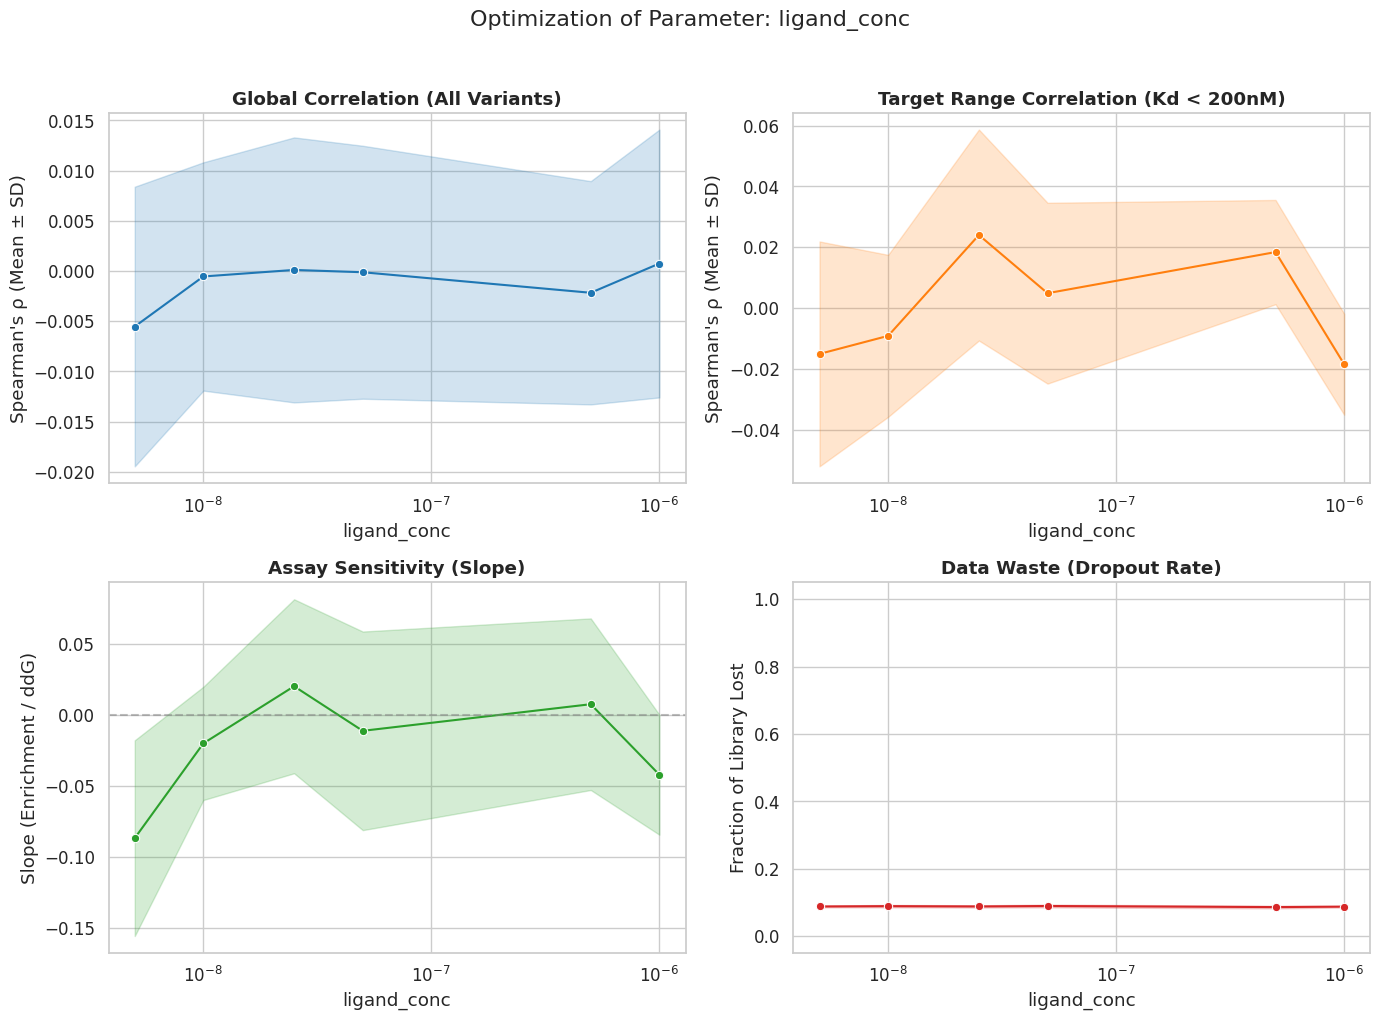

In [86]:
param_to_optimize = "ligand_conc"
vals_to_test = [1000e-9, 500e-9, 50e-9, 25e-9, 10e-9, 5e-9]

ligand_df = screen_parameter(gb1_df, param_to_optimize, vals_to_test, params, n_replicates=10)
fig = plot_optimization_results(ligand_df, param_to_optimize, log_x=True)
fig.show()

/tmp/ipykernel_3088/4037522408.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


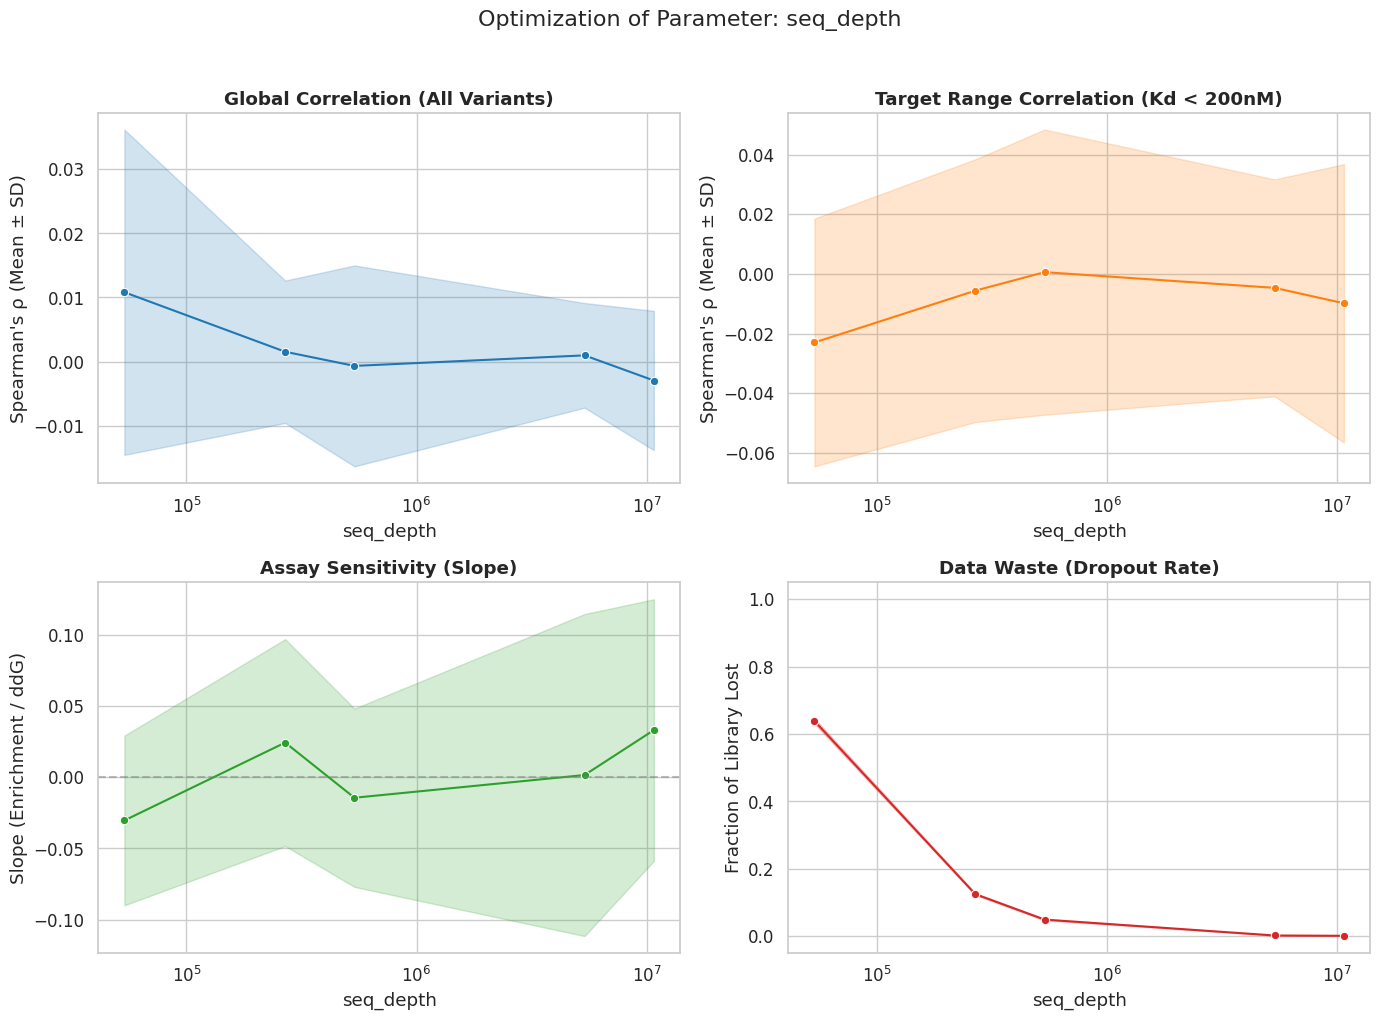

In [87]:
param_to_optimize = "seq_depth"
vals_to_test = [len(gb1_df) * 20, len(gb1_df) * 10, len(gb1_df) * 1, int(len(gb1_df) * .5), int(len(gb1_df) * .1)]

ligand_df = screen_parameter(gb1_df, param_to_optimize, vals_to_test, params, n_replicates=10)
fig = plot_optimization_results(ligand_df, param_to_optimize, log_x=True)
fig.show()

/tmp/ipykernel_3088/4293767149.py:7: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


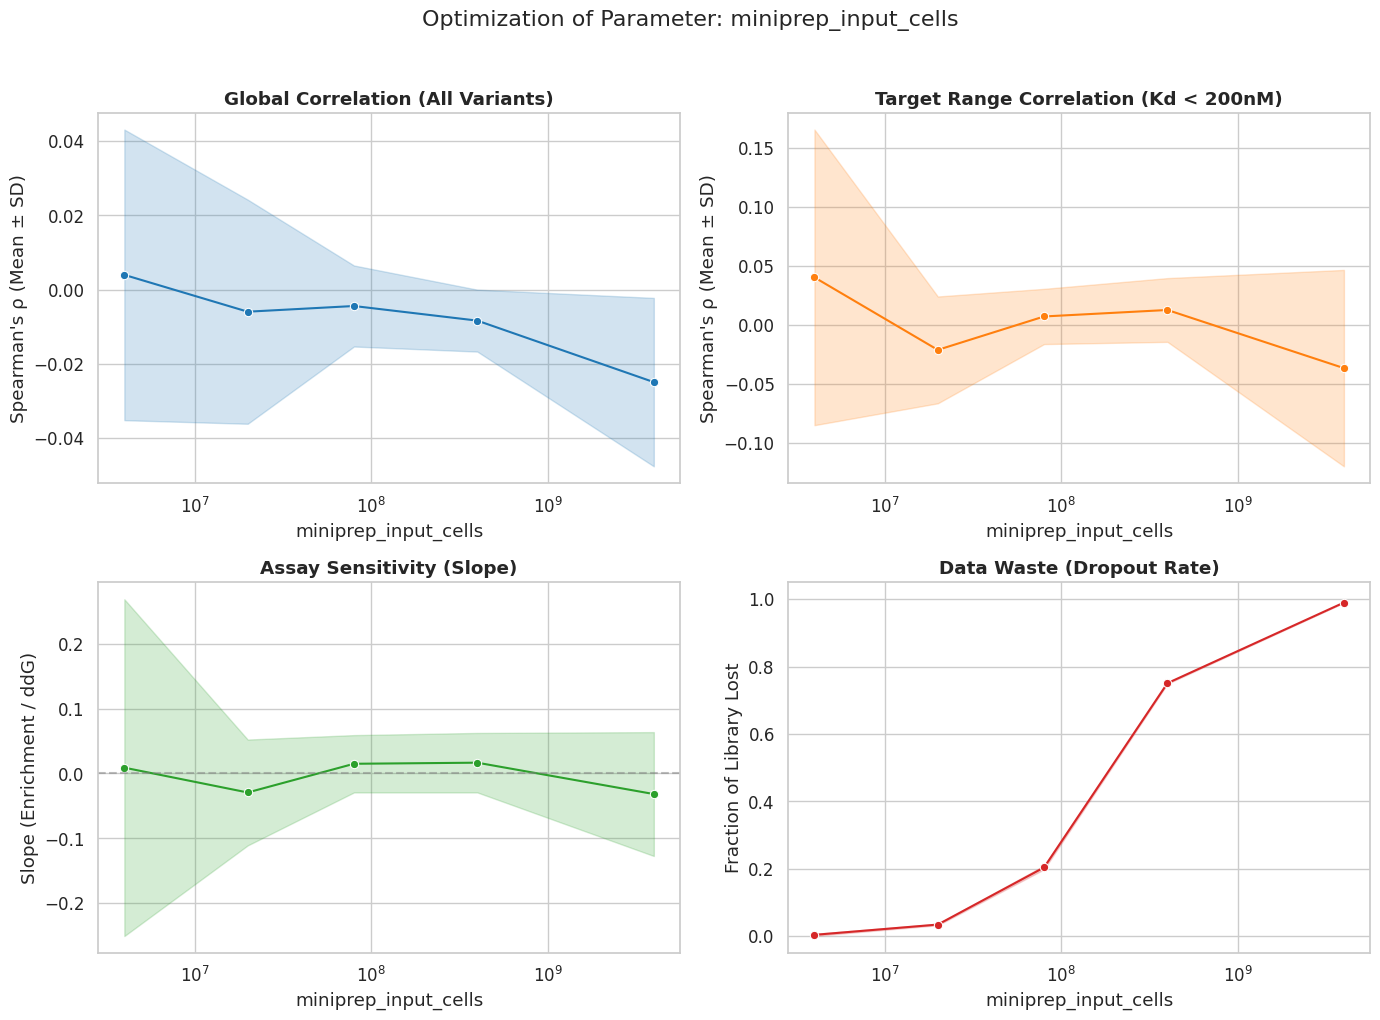

In [88]:
param_to_optimize = "miniprep_input_cells"
vals_to_test = [100, 10, 2, 0.5, 0.1]
vals_to_test = list(map(lambda x: int(x * params['miniprep_input_cells']), vals_to_test))

ligand_df = screen_parameter(gb1_df, param_to_optimize, vals_to_test, params, n_replicates=10)
fig = plot_optimization_results(ligand_df, param_to_optimize, log_x=True)
fig.show()

/tmp/ipykernel_3088/380403064.py:18: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


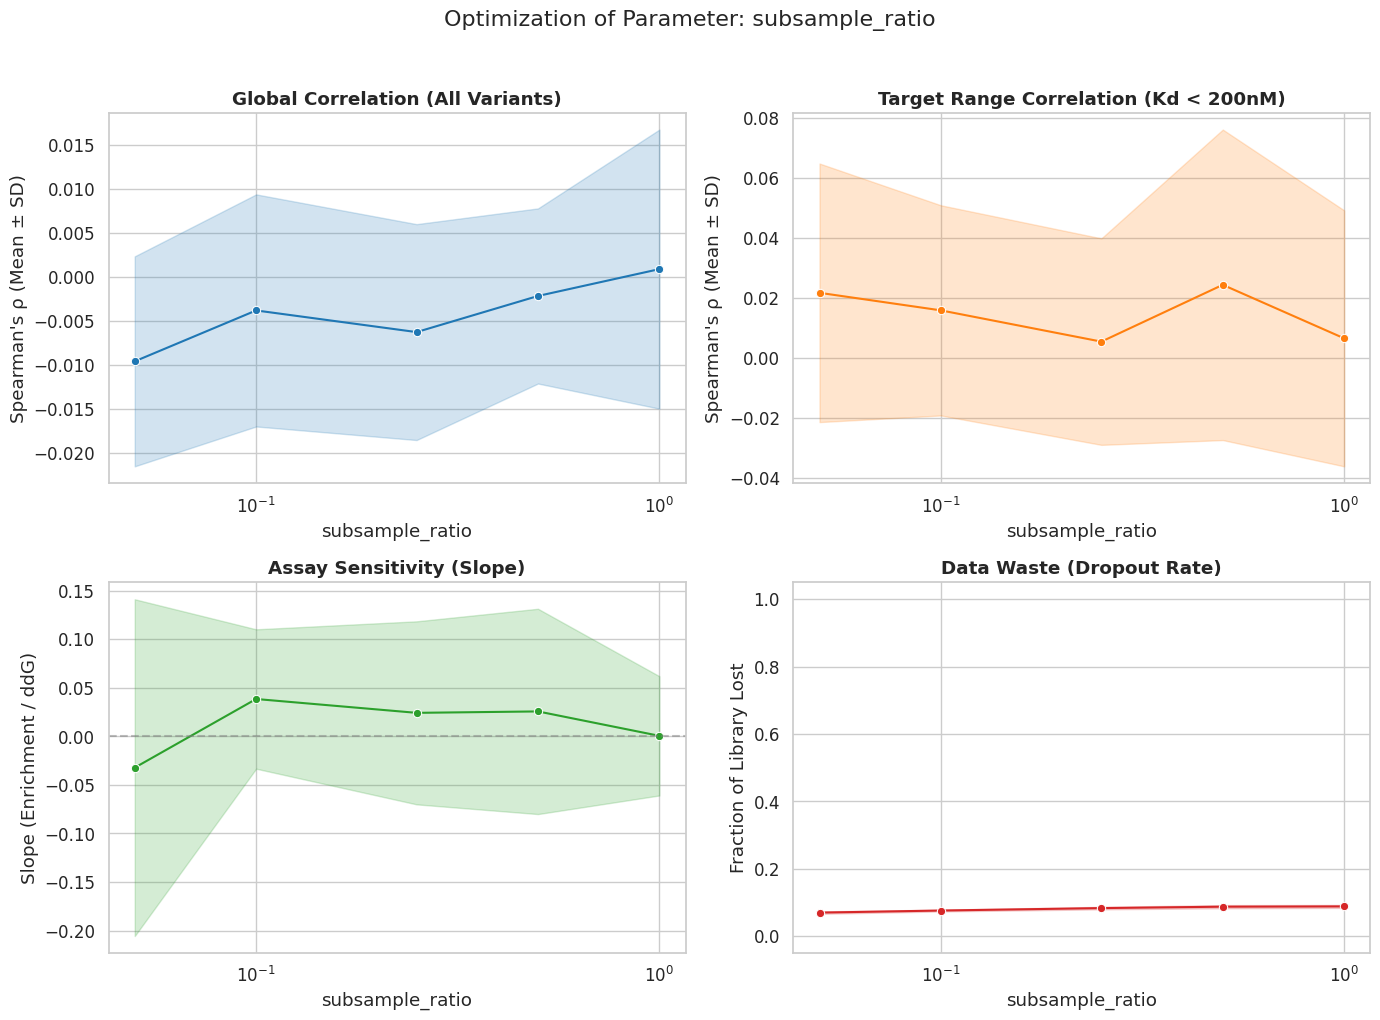

In [89]:
# Special set up to test library subsampling prior to experimentation
subsample_ratios = [1, 0.5, 0.25, 0.1, 0.05]
results = []

for ratio in subsample_ratios:
    subsample_df = gb1_df.sample(frac=ratio)

    # setup dummy optmization
    param_to_optimize = "seq_depth"
    vals_to_test = [params[param_to_optimize]]

    result_df = screen_parameter(subsample_df, param_to_optimize, vals_to_test, params, n_replicates=10)
    result_df['subsample_ratio'] = ratio
    results.append(result_df)

results_df = pd.concat(results, axis=0)
fig = plot_optimization_results(results_df, "subsample_ratio", log_x=True)
fig.show()


/tmp/ipykernel_3088/1253074661.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


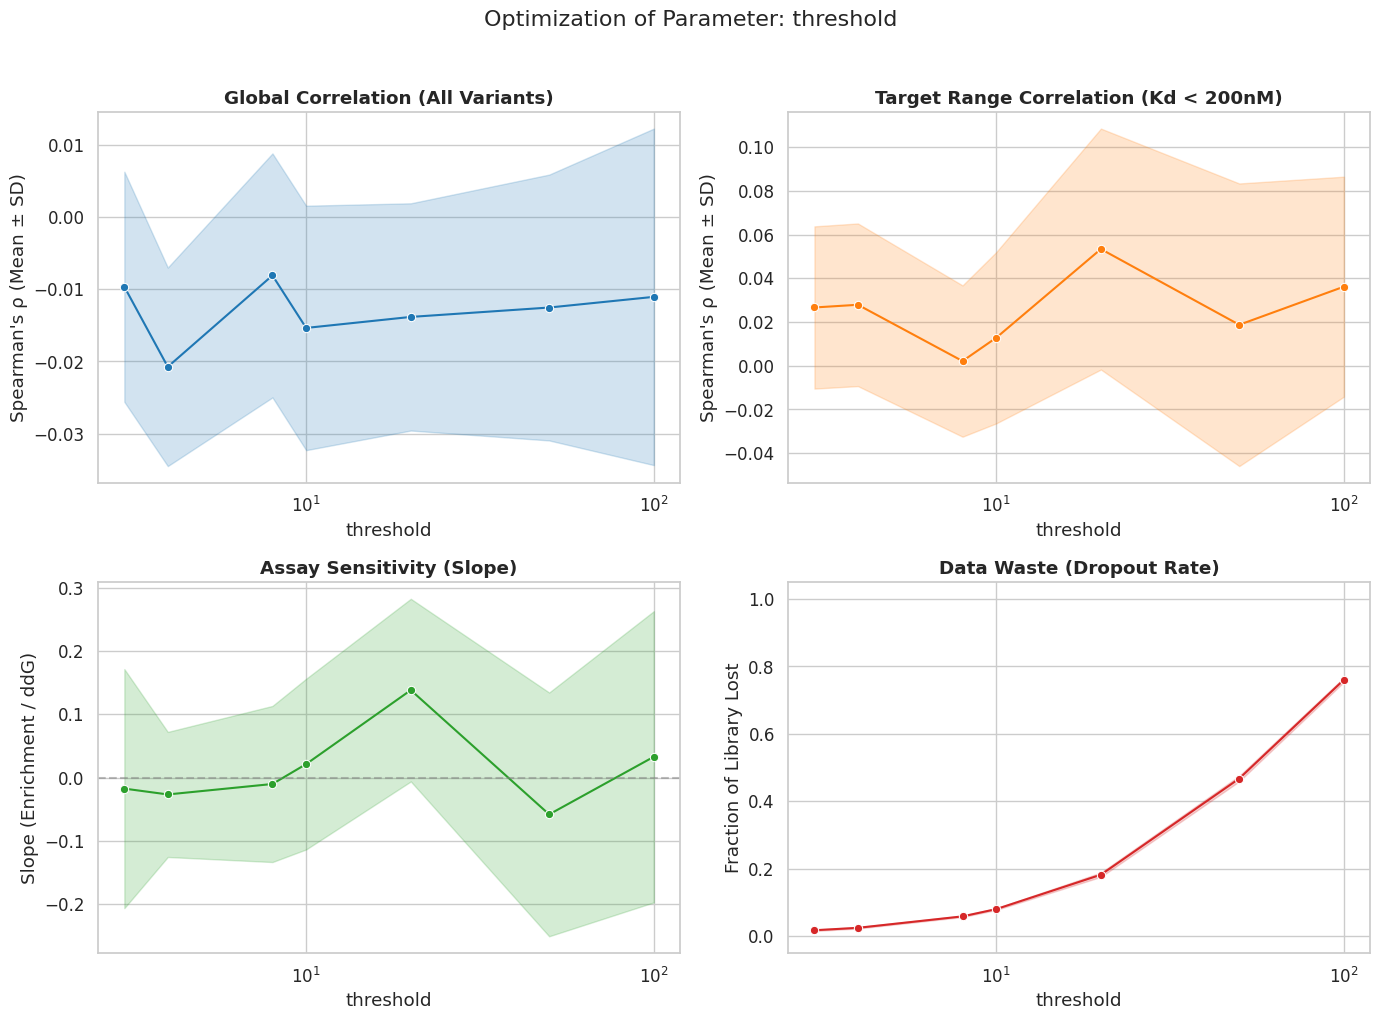

In [90]:
# Special set up to test read count thresholds
thresholds = [100, 50, 20, 10, 8, 4, 3]
results = []

for thresh in thresholds:
    # setup dummy optmization
    param_to_optimize = "seq_depth"
    vals_to_test = [params[param_to_optimize]]

    result_df = screen_parameter(subsample_df, param_to_optimize, vals_to_test, params, read_count_threshold = thresh, n_replicates=10)
    result_df['threshold'] = thresh
    results.append(result_df)

results_df = pd.concat(results, axis=0)
fig = plot_optimization_results(results_df, "threshold", log_x=True)
fig.show()

Clearly, things aren't looking too good for Y2H and a basic enrichment score. Let's take a look at the relationship in between p_bind, p_fold and enrichment in our baseline experiment. 

In [93]:
import plotly.express as px

wt_lib = exp_df.loc[exp_df.aa_substitutions == '', 'lib_read_counts'].sum()
wt_sort = exp_df.loc[exp_df.aa_substitutions == '', 'sel_read_counts'].sum()
exp_df['enrichment'] = np.log2(((exp_df.sel_read_counts + 1) / (wt_sort + 1))/((exp_df.lib_read_counts + 1) / (wt_lib + 1)))
#exp_df['enrichment'] = np.log2(((exp_df.sel_read_counts + 1) / (exp_df.sel_read_counts.sum() + 1))/((exp_df.lib_read_counts + 1) / (exp_df.lib_read_counts.sum() + 1)))

fig = px.scatter(exp_df.loc[exp_df.lib_read_counts >= 10], "p_fold", "p_bind", color="enrichment")
fig.show()

In [95]:
fig = px.scatter(exp_df.loc[exp_df.lib_read_counts >= 10], "count", "enrichment")
fig.show()

In [166]:
subsample_df = gb1_df.sample(frac=0.1)

params = {
    'num_cells_inoc': 1e8,
    'RT': 0.001987 * 298.15,
    'wt_dG_fold': -4.8,
    'wt_dG_bind': -9.0,
    'ligand_conc': 10e-9,
    'hill_coeff': 1.0,
    'max_growth_rate': 0.20,
    'sel_percent': 0.025 / 0.20,
    'inhibitor_percent': 0.1,
    'inhibitor_concentration': 10e-3,
    'time': 30,
    'miniprep_input_cells': 4e7,
    'plasmid_copy_number': 1,
    'miniprep_efficiency': 0.0016,
    'elution_vol': 10,
    'template_vol': 1,
    'pcr_cycles': 25,
    'pcr_efficiency': 0.9,
    'pcr_noise': 1.5,
    'seq_depth': 350_000
}

exp_df = simulate_experiment(subsample_df, **params).copy()
wt_lib = exp_df.loc[exp_df.aa_substitutions == '', 'lib_read_counts'].sum()
wt_sort = exp_df.loc[exp_df.aa_substitutions == '', 'sel_read_counts'].sum()
exp_df['enrichment'] = np.log2(((exp_df.sel_read_counts + 1) / (wt_sort + 1))/((exp_df.lib_read_counts + 1) / (wt_lib + 1)))

exp_df

,aa_substitutions,ddG_fold,ddG_bind,count,n_cells_pelleted,n_plasmids_eluted,Tv,n_amplicons,lib_read_counts,dG_fold,p_fold,dG_bind,Kd_variant,p_bind,S_rel,growth_rate,sel_count,sel_read_counts,enrichment
152249,K10V T25C,1.446619,-0.295604,90,49,0,0,0.000000e+00,0,-3.353381,0.996531,-9.295604,1.533114e-07,6.123271e-02,1.602320e+00,3.022584e-02,222.869154,0,0.000000
395171,K28S G41L,-14.312855,8.945510,553,125,0,0,0.000000e+00,0,-19.112855,1.000000,-0.054490,9.121253e-01,1.096341e-08,2.878859e-07,6.397465e-09,553.000106,0,0.000000
49177,K4H K31F,1.628893,15.430171,130,21,0,0,0.000000e+00,0,-3.171107,0.995287,6.430171,5.174076e+04,1.932712e-13,5.051153e-12,1.122479e-13,130.000000,0,0.000000
147381,K10H L12V,0.963376,1.279467,483,109,0,0,0.000000e+00,0,-3.836624,0.998463,-7.720533,2.188913e-06,4.547702e-03,1.192336e-01,2.614992e-03,522.417155,0,0.000000
156523,K10R N37A,-0.018516,1.376206,513,126,0,0,0.000000e+00,0,-4.818516,0.999707,-7.623794,2.577184e-06,3.865206e-03,1.014659e-01,2.229661e-03,548.488143,0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
369844,A26P K28L,7.806015,3.155610,574,126,0,0,0.000000e+00,0,3.006015,0.006218,-5.844390,5.195081e-05,1.924527e-04,3.142240e-05,6.982732e-07,574.012024,0,0.000000
12410,Q2L A34E,-2.461346,8.875085,2729,598,1,1,3.042696e+06,163,-7.261346,0.999995,-0.124915,8.098927e-01,1.234731e-08,3.242242e-07,7.204981e-09,2729.000590,13,-3.550197
295496,E19Q T53I,1.083074,0.137486,674,247,0,0,0.000000e+00,0,-3.716926,0.998119,-8.862514,3.184668e-07,3.044448e-02,7.979319e-01,1.628776e-02,1098.678026,0,0.000000
378170,A26Q T51P,12.191397,6.329224,2547,572,1,0,0.000000e+00,0,7.391397,0.000004,-2.670776,1.101810e-02,9.075968e-07,9.092378e-11,2.020528e-12,2547.000000,0,0.000000


In [167]:
spearmanr(exp_df["count"], exp_df["sel_count"])

SignificanceResult(statistic=np.float64(0.8607794336556813), pvalue=np.float64(0.0))

Well that makes more sense now. If you compare this with the equivalent plot from `simulate_experiment.ipynb`, you can see that high enrichment points for Y2H

## Conclusion

Based on these initial experiments, there doesn't seem to be much support that Y2H will be effective at parsing